In [4]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import KFold
import sklearn.linear_model as lm

from utils import Preprocessor, compute_error

seed = 42
np.random.seed(seed)

sns.set_style('darkgrid')
sns.set_theme(font_scale=1.5)


df = pd.read_csv("data/heartDisease.csv")
df = df.drop(labels=["row.names"], axis=1)


In [10]:
kf = KFold(n_splits=10,shuffle=True, random_state=seed)

lams = np.arange(0, 100, 0.5)

train_error_avgs = []
test_error_avgs = []

for lam in tqdm(lams):
    linear_regression_regularized = lm.Ridge(alpha=lam)

    kfold_train_errors = []
    kfold_test_errors = []

    for i, (train_index, test_index) in enumerate(kf.split(df)):
        preprocessor = Preprocessor(task="regression")
        n_train = len(train_index)
        n_test = len(test_index)
        
        df_fold_train = df.iloc[train_index]
        df_fold_test = df.iloc[test_index]

        X_fold_train, y_fold_train = preprocessor.fit_transform(df_fold_train)
        X_fold_test, y_fold_test = preprocessor.transform(df_fold_test)

        linear_regression_regularized.fit(X_fold_train, y_fold_train)
        y_train_hat = linear_regression_regularized.predict(X_fold_train)
        y_test_hat = linear_regression_regularized.predict(X_fold_test)
    
        train_error = compute_error(y_true=y_fold_train, y_pred=y_train_hat)
        test_error = compute_error(y_true=y_fold_test, y_pred=y_test_hat)

        kfold_train_errors.append(train_error)
        kfold_test_errors.append(test_error)

    train_error_avgs.append(np.average(kfold_train_errors))
    test_error_avgs.append(np.average(kfold_test_errors))




  0%|          | 0/200 [00:00<?, ?it/s]/Users/krusand/Documents/GitHub/02452-ML-Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.85907e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/krusand/Documents/GitHub/02452-ML-Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.2314e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
100%|██████████| 200/200 [00:17<00:00, 11.33it/s]


<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/var/folders/3h/hhvlktwj1rzfznpk5wz5w45w0000gn/T/ipykernel_78975/3614913453.py:5: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("$\lambda$")


Text(0, 0.5, 'Mean error')

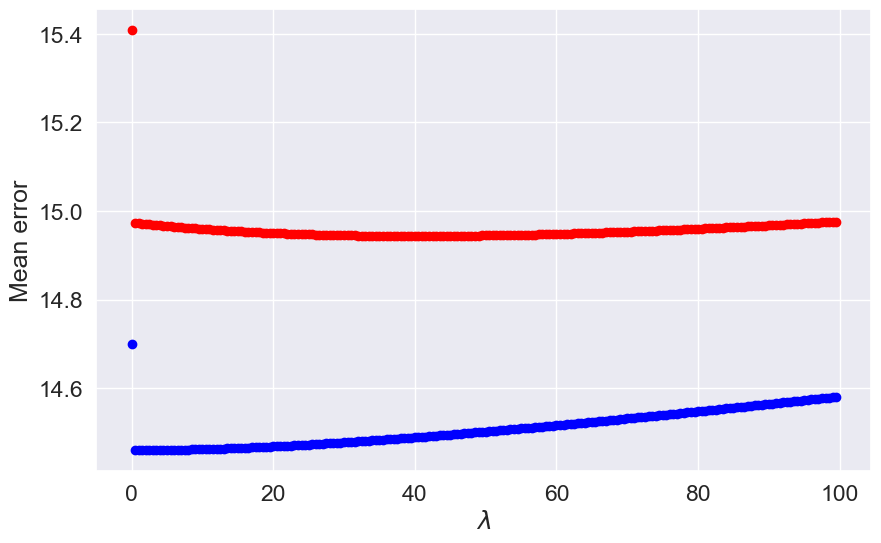

In [11]:

fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(lams, test_error_avgs, c='red')
ax.scatter(lams, train_error_avgs, c='blue')
ax.set_xlabel("$\lambda$")
ax.set_ylabel("Mean error")

In [12]:

best_lam = lams[np.argmin(test_error_avgs)]

best_lm = lm.Ridge(alpha=best_lam)

preprocessor = Preprocessor(task='regression')

X_preprocessed, y = preprocessor.fit_transform(df)

best_lm.fit(X_preprocessed, y)


for coef, feature_name in zip(best_lm.coef_, preprocessor.get_feature_names_out().tolist()):
    print(feature_name, "\t\t", coef)



num__sbp 		 0.540493109004093
num__tobacco 		 -0.19532356591539118
num__ldl 		 1.0396075716349802
num__typea 		 0.36227452142782596
num__alcohol 		 0.19494142439358814
num__age 		 0.788060296433845
cat__chd_0 		 0.23935430599931132
cat__chd_1 		 -0.2393543059993134
cat__famhist_Absent 		 -0.12644460068716737
cat__famhist_Present 		 0.12644460068716734


The coefficients mean that:
- High LDL choleresterol is highly predictive of obesity
- As you age, the more obese you become
- A high systolic blood pressure is also predictive of a high obesity. 

- It looks like tobacco is negatively associated with obesity, and quite a lot. We must remember that it is on the log transformed scale, meaning that the coefficient relates to a multiplication
